# Thailand Road Accident Analysis (2019-2022)
### CPE393 - Introduction to Data Science with Python | Summer 2026 | KMUTT

**Group:** BRQ
**Members:** Baptiste LORTON, Romain BARDET, Quentin COUPÉ

**Dataset source:** Kaggle - "Thailand Road Accident (2019-2022)", originally sourced from the
Office of the Permanent Secretary, Ministry of Transport (Thailand).


## 1. Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)


## 2. Dataset Description

In [4]:
# [Baptiste] - Data loading and initial inspection
df = pd.read_csv("thai_road_accident_2019_2022.csv")
print("Shape:", df.shape)
df.head()


Shape: (81735, 18)


,acc_code,incident_datetime,report_datetime,province_th,province_en,agency,route,vehicle_type,presumed_cause,accident_type,number_of_vehicles_involved,number_of_fatalities,number_of_injuries,weather_condition,latitude,longitude,road_description,slope_description
0,571905,2019-01-01 00:00:00,2019-01-02 06:11:00,ลพบุรี,Loburi,department of rural roads,แยกทางหลวงหมายเลข 21 (กม.ที่ 31+000) - บ้านวัง...,motorcycle,driving under the influence of alcohol,other,1,0,2,clear,14.959105,100.873463,straight road,no slope
1,3790870,2019-01-01 00:03:00,2020-02-20 13:48:00,อุบลราชธานี,Ubon Ratchathani,department of highways,เดชอุดม - อุบลราชธานี,private/passenger car,speeding,rollover/fallen on straight road,1,0,2,clear,15.210738,104.862689,straight road,no slope
2,599075,2019-01-01 00:05:00,2019-01-01 10:35:00,ประจวบคีรีขันธ์,Prachuap Khiri Khan,department of highways,ปราณบุรี - ปากน้ำปราณ,motorcycle,speeding,head-on collision (not overtaking),2,1,0,clear,12.374259,99.907949,wide curve,slope area
3,571924,2019-01-01 00:20:00,2019-01-02 05:12:00,เชียงใหม่,Chiang Mai,department of rural roads,เชื่อมทางหลวงหมายเลข 1013 (กม.ที่ 8+200) - บ้า...,motorcycle,driving under the influence of alcohol,other,1,0,1,clear,18.601721,98.804204,straight road,no slope
4,599523,2019-01-01 00:25:00,2019-01-04 09:42:00,นครสวรรค์,Nakhon Sawan,department of highways,เกยไชย - ศรีมงคล,private/passenger car,cutting in closely by people/vehicles/animals,rollover/fallen on straight road,1,0,0,clear,15.866389,100.590010,straight road,no slope


In [5]:
# [Baptiste] - Column types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 81735 entries, 0 to 81734
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   acc_code                     81735 non-null  int64  
 1   incident_datetime            81735 non-null  str    
 2   report_datetime              81735 non-null  str    
 3   province_th                  81735 non-null  str    
 4   province_en                  81735 non-null  str    
 5   agency                       81735 non-null  str    
 6   route                        81735 non-null  str    
 7   vehicle_type                 81735 non-null  str    
 8   presumed_cause               81735 non-null  str    
 9   accident_type                81735 non-null  str    
 10  number_of_vehicles_involved  81735 non-null  int64  
 11  number_of_fatalities         81735 non-null  int64  
 12  number_of_injuries           81735 non-null  int64  
 13  weather_condition          

In [6]:
# [Baptiste] - Descriptive statistics for all columns
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acc_code,81735.0,NaN,NaN,NaN,4235766.317061,2128207.455614,571834.0,3789459.5,3824084.0,5831088.5,7571316.0
incident_datetime,81735,67917,2020-12-30 19:00:00,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
report_datetime,81735,66234,2022-12-29 11:39:00,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_th,81735,78,กรุงเทพมหานคร,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province_en,81735,78,Bangkok,6439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency,81735,3,department of highways,75304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,81735,3882,ไม่ทราบ,2060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,81735,15,4-wheel pickup truck,28445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presumed_cause,81735,54,speeding,60373,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident_type,81735,11,rollover/fallen on straight road,33046,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Assessment

In [7]:
# [Baptiste] - Check for missing values and duplicate rows
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

# Duplicate rows
print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated acc_code:", df['acc_code'].duplicated().sum())


Missing values per column:
latitude     359
longitude    359
dtype: int64

Fully duplicated rows: 0
Duplicated acc_code: 0


In [8]:
# [Baptiste] - Data types check: dates are read as plain text (object), not real datetimes
print(df.dtypes)
print("\nincident_datetime and report_datetime are currently text, not datetime objects.")
print("This must be fixed before any date arithmetic (e.g. report delay, hour extraction).")


acc_code                         int64
incident_datetime                  str
report_datetime                    str
province_th                        str
province_en                        str
agency                             str
route                              str
vehicle_type                       str
presumed_cause                     str
accident_type                      str
number_of_vehicles_involved      int64
number_of_fatalities             int64
number_of_injuries               int64
weather_condition                  str
latitude                       float64
longitude                      float64
road_description                   str
slope_description                  str
dtype: object

incident_datetime and report_datetime are currently text, not datetime objects.
This must be fixed before any date arithmetic (e.g. report delay, hour extraction).


In [9]:
# [Baptiste] - Outlier check (IQR method) on the count columns
for c in ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries']:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_outliers = (df[c] > upper).sum()
    print(f"{c}: IQR upper bound = {upper}, max value = {df[c].max()}, rows above bound = {n_outliers}")


number_of_vehicles_involved: IQR upper bound = 3.5, max value = 27, rows above bound = 1995
number_of_fatalities: IQR upper bound = 0.0, max value = 13, rows above bound = 10135
number_of_injuries: IQR upper bound = 2.5, max value = 51, rows above bound = 5138


In [10]:
# [Baptiste] - Report delay check (using datetime parsing)
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'])
df['report_datetime'] = pd.to_datetime(df['report_datetime'])
df['report_delay_days'] = (df['report_datetime'] - df['incident_datetime']).dt.total_seconds() / 86400

print("Report delay > 30 days:", (df['report_delay_days'] > 30).mean().round(3), "of rows")
print("Median delay (days):", df['report_delay_days'].median())
print("Negative delay (report before incident):", (df['report_delay_days'] < 0).sum())


Report delay > 30 days: 0.598 of rows
Median delay (days): 48.72083333333333
Negative delay (report before incident): 1


In [11]:
# [Baptiste] - Check physically inconsistent values and GPS coordinates
print("Rows with 0 vehicles involved:", (df['number_of_vehicles_involved'] == 0).sum())

# GPS out of Thailand's approximate bounding box (lat 5-21, lon 97-106)
out_of_thailand = df[(df['latitude'] < 5) | (df['latitude'] > 21) |
                      (df['longitude'] < 97) | (df['longitude'] > 106)]
print("Coordinates outside Thailand bounding box:", len(out_of_thailand))
out_of_thailand[['acc_code', 'latitude', 'longitude', 'province_en']]


Rows with 0 vehicles involved: 109
Coordinates outside Thailand bounding box: 3


,acc_code,latitude,longitude,province_en
12264,573720,41.549515,85.718742,unknown
18344,575103,-0.001108,18.017161,unknown
40088,2904953,39.887517,67.583519,unknown


## 4. Data Cleaning and Preprocessing


In [ ]:
# [Baptiste] - Drop physically inconsistent rows and out-of-bounds GPS
df_clean = df.copy()

# 1. Drop physically inconsistent rows
before = len(df_clean)
df_clean = df_clean[df_clean['number_of_vehicles_involved'] > 0]
print(f"Dropped {before - len(df_clean)} rows with 0 vehicles involved")

# 2. Drop GPS coordinates outside Thailand's bounding box
before = len(df_clean)
df_clean = df_clean[~((df_clean['latitude'] < 5) | (df_clean['latitude'] > 21) |
                       (df_clean['longitude'] < 97) | (df_clean['longitude'] > 106) |
                       (df_clean['latitude'].isna() & False))] 

print(f"Dropped {before - len(df_clean)} rows with out-of-Thailand coordinates")

print("Remaining rows:", len(df_clean))


Dropped 109 rows with 0 vehicles involved
Dropped 3 rows with out-of-Thailand coordinates
Remaining rows: 81623


In [13]:
# [Baptiste] - Normalize text categories and extract time features from incident_datetime
# 3. Check for inconsistent text formatting (extra spaces, casing) in categorical columns
cat_cols = ['province_en', 'agency', 'vehicle_type', 'presumed_cause', 'accident_type',
            'weather_condition', 'road_description', 'slope_description']
for c in cat_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip().str.lower()

# 4. Extract time-based features from incident_datetime (reliable timestamp)
df_clean['year'] = df_clean['incident_datetime'].dt.year
df_clean['month'] = df_clean['incident_datetime'].dt.month
df_clean['hour'] = df_clean['incident_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['incident_datetime'].dt.day_name()
df_clean['is_weekend'] = df_clean['incident_datetime'].dt.dayofweek >= 5

df_clean[['incident_datetime', 'year', 'month', 'hour', 'day_of_week', 'is_weekend']].head()


,incident_datetime,year,month,hour,day_of_week,is_weekend
0,2019-01-01 00:00:00,2019,1,0,Tuesday,False
1,2019-01-01 00:03:00,2019,1,0,Tuesday,False
2,2019-01-01 00:05:00,2019,1,0,Tuesday,False
3,2019-01-01 00:20:00,2019,1,0,Tuesday,False
4,2019-01-01 00:25:00,2019,1,0,Tuesday,False


In [14]:
# [Baptiste] - Engineer the target variable: accident_severity
def severity(row):
    if row['number_of_fatalities'] > 0:
        return 'Fatal'
    elif row['number_of_injuries'] > 0:
        return 'Injury'
    else:
        return 'PDO'  # Property Damage Only

df_clean['accident_severity'] = df_clean.apply(severity, axis=1)
df_clean['accident_severity'].value_counts(normalize=True).round(3)


accident_severity
Injury    0.445
PDO       0.431
Fatal     0.124
Name: proportion, dtype: float64

In [ ]:
# [Baptiste] - Drop non-predictive and leakage-prone columns
df_model = df_clean.drop(columns=['acc_code', 'report_datetime', 'report_delay_days',
                                   'province_th', 'route', 'incident_datetime'])
print("Final cleaned shape:", df_model.shape)
df_model.head()


Final cleaned shape: (81623, 19)


,province_en,agency,vehicle_type,presumed_cause,accident_type,number_of_vehicles_involved,number_of_fatalities,number_of_injuries,weather_condition,latitude,longitude,road_description,slope_description,year,month,hour,day_of_week,is_weekend,accident_severity
0,loburi,department of rural roads,motorcycle,driving under the influence of alcohol,other,1,0,2,clear,14.959105,100.873463,straight road,no slope,2019,1,0,Tuesday,False,Injury
1,ubon ratchathani,department of highways,private/passenger car,speeding,rollover/fallen on straight road,1,0,2,clear,15.210738,104.862689,straight road,no slope,2019,1,0,Tuesday,False,Injury
2,prachuap khiri khan,department of highways,motorcycle,speeding,head-on collision (not overtaking),2,1,0,clear,12.374259,99.907949,wide curve,slope area,2019,1,0,Tuesday,False,Fatal
3,chiang mai,department of rural roads,motorcycle,driving under the influence of alcohol,other,1,0,1,clear,18.601721,98.804204,straight road,no slope,2019,1,0,Tuesday,False,Injury
4,nakhon sawan,department of highways,private/passenger car,cutting in closely by people/vehicles/animals,rollover/fallen on straight road,1,0,0,clear,15.866389,100.590010,straight road,no slope,2019,1,0,Tuesday,False,PDO


## 5. Exploratory Data Analysis (EDA)

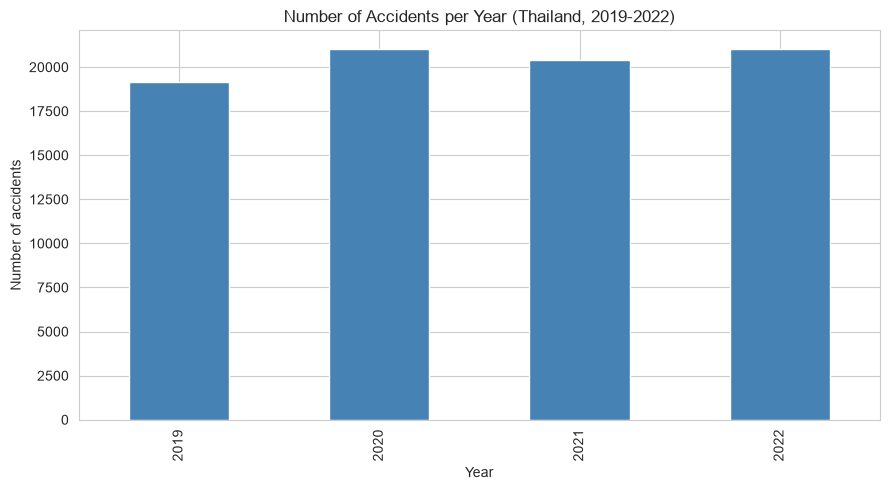

In [16]:
# [Romain] - Accidents per year
fig, ax = plt.subplots()
df_clean['year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Number of Accidents per Year (Thailand, 2019-2022)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of accidents")
plt.tight_layout()
plt.show()


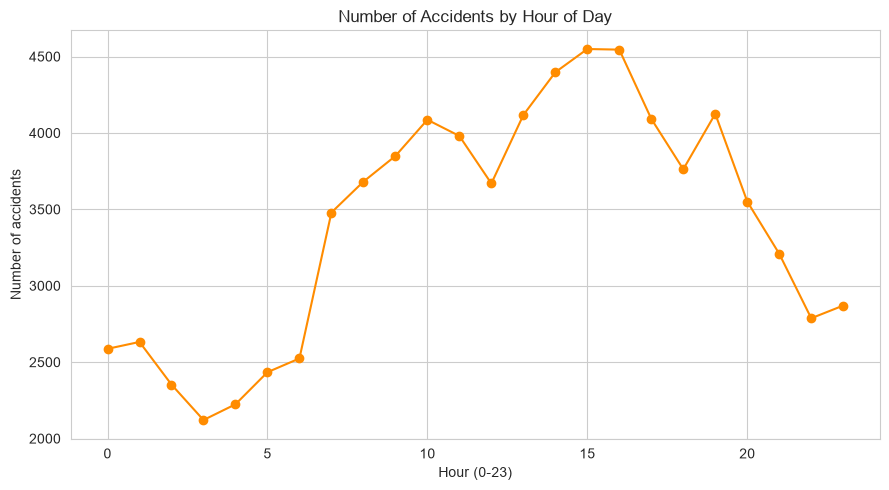

In [36]:
# [Romain] - Accidents by hour of day
fig, ax = plt.subplots()
df_clean['hour'].value_counts().sort_index().plot(kind='line', marker='o', ax=ax, color='darkorange')
ax.set_title("Number of Accidents by Hour of Day")
ax.set_xlabel("Hour (0-23)")
ax.set_ylabel("Number of accidents")
plt.tight_layout()
plt.show()


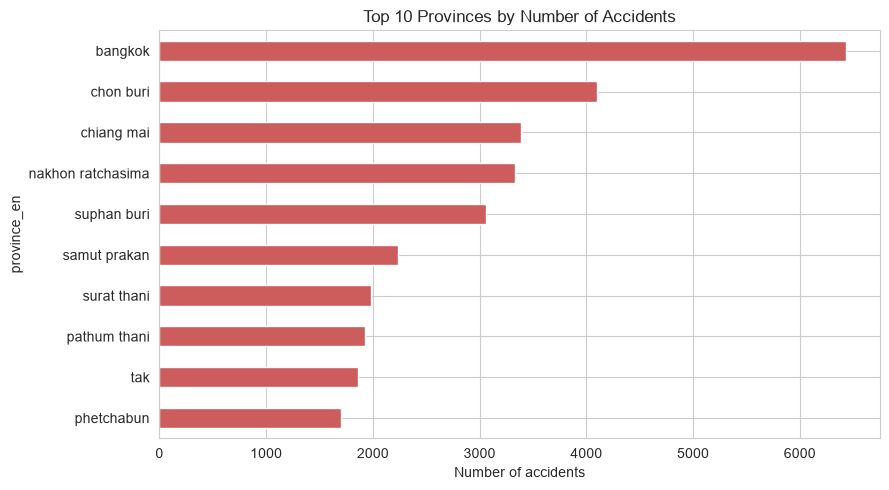

In [18]:
# [Romain] - Top 10 provinces by accident count
top_provinces = df_clean['province_en'].value_counts().head(10)
fig, ax = plt.subplots()
top_provinces.plot(kind='barh', ax=ax, color='indianred')
ax.set_title("Top 10 Provinces by Number of Accidents")
ax.set_xlabel("Number of accidents")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


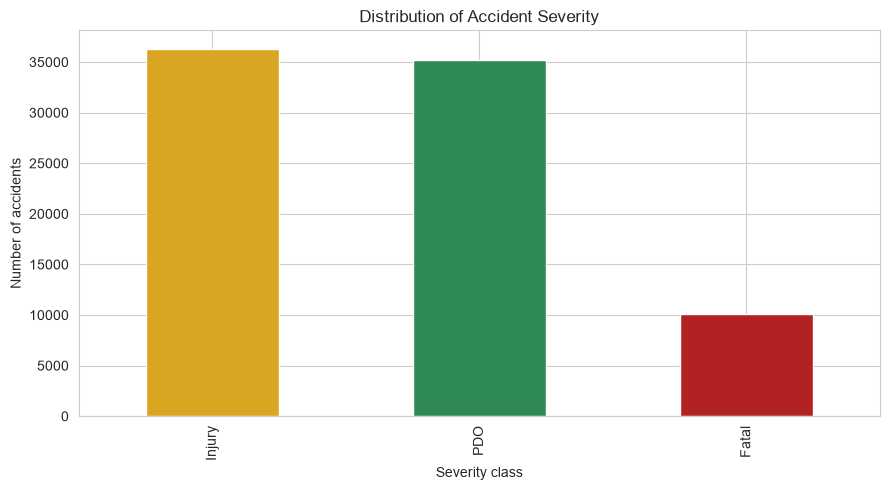

In [38]:
# [Romain] - Severity distribution overall
fig, ax = plt.subplots()
df_clean['accident_severity'].value_counts().plot(kind='bar', ax=ax, color=['goldenrod','seagreen','firebrick'])
ax.set_title("Distribution of Accident Severity")
ax.set_xlabel("Severity class")
ax.set_ylabel("Number of accidents")
plt.tight_layout()
plt.show()


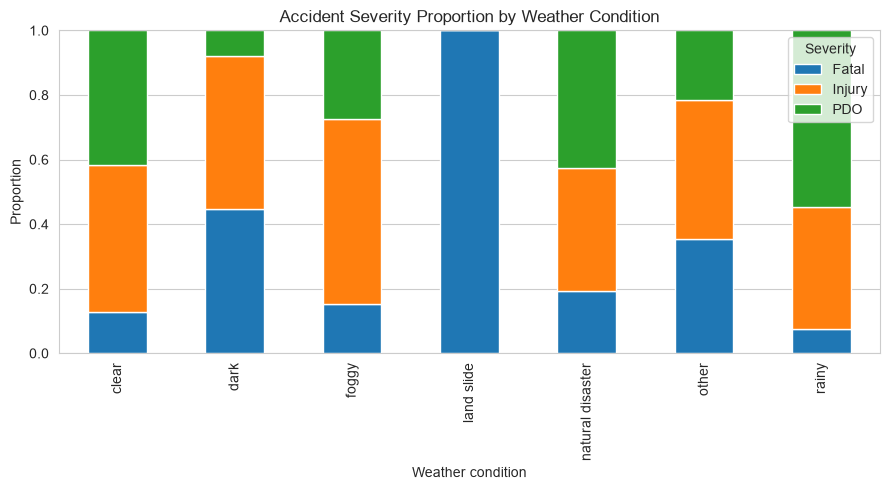

In [42]:
# [Romain] - Severity by weather condition
sev_weather = pd.crosstab(df_clean['weather_condition'], df_clean['accident_severity'], normalize='index')
fig, ax = plt.subplots(figsize=(9,5))
sev_weather.plot(kind='bar', stacked=True, ax=ax)
ax.set_title("Accident Severity Proportion by Weather Condition")
ax.set_xlabel("Weather condition")
ax.set_ylabel("Proportion")
ax.legend(title="Severity")
plt.tight_layout()
plt.show()


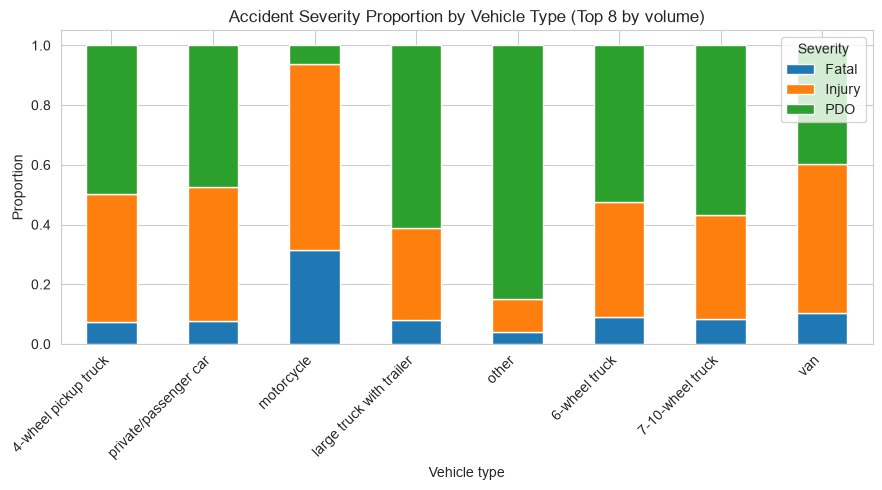

In [21]:
# [Romain] - Severity by vehicle type
sev_vehicle = pd.crosstab(df_clean['vehicle_type'], df_clean['accident_severity'], normalize='index')
sev_vehicle = sev_vehicle.loc[df_clean['vehicle_type'].value_counts().head(8).index]
fig, ax = plt.subplots(figsize=(9,5))
sev_vehicle.plot(kind='bar', stacked=True, ax=ax)
ax.set_title("Accident Severity Proportion by Vehicle Type (Top 8 by volume)")
ax.set_xlabel("Vehicle type")
ax.set_ylabel("Proportion")
ax.legend(title="Severity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


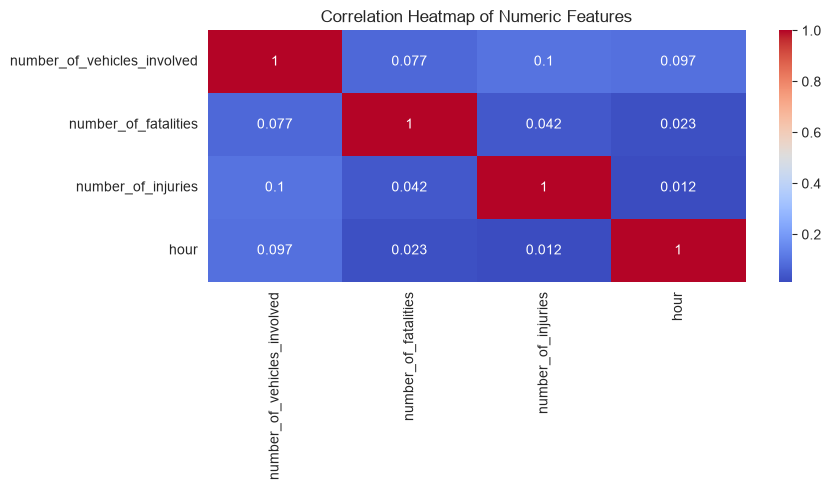

In [ ]:
# [Romain] - Correlation heatmap for numeric features
numeric_cols = ['number_of_vehicles_involved', 'number_of_fatalities', 'number_of_injuries', 'hour']
fig, ax = plt.subplots()
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()


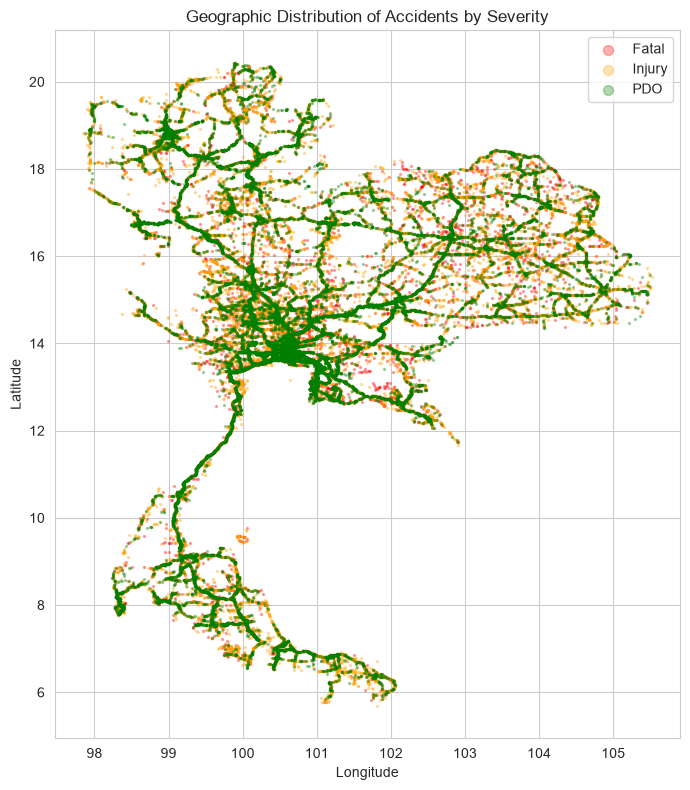

In [ ]:
# [Romain] - Geospatial scatter (rows with valid GPS only)
geo = df_clean.dropna(subset=['latitude', 'longitude'])
fig, ax = plt.subplots(figsize=(7,8))
colors = {'Fatal': 'red', 'Injury': 'orange', 'PDO': 'green'}
for sev_class, c in colors.items():
    subset = geo[geo['accident_severity'] == sev_class]
    ax.scatter(subset['longitude'], subset['latitude'], s=2, alpha=0.3, label=sev_class, color=c)
ax.set_title("Geographic Distribution of Accidents by Severity")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()


## 6. Feature Engineering

In [ ]:
# [Romain] - Feature engineering: province grouping, define feature matrix and target
top_15_provinces = df_model['province_en'].value_counts().head(15).index
df_model['province_grouped'] = df_model['province_en'].where(
    df_model['province_en'].isin(top_15_provinces), 'other_province'
)

feature_cols = ['vehicle_type', 'weather_condition', 'road_description', 'slope_description',
                 'agency', 'accident_type', 'day_of_week', 'province_grouped',
                 'number_of_vehicles_involved', 'hour', 'month', 'is_weekend']

X = df_model[feature_cols].copy()
y = df_model['accident_severity'].copy()

categorical_features = ['vehicle_type', 'weather_condition', 'road_description', 'slope_description',
                         'agency', 'accident_type', 'day_of_week', 'province_grouped']
numeric_features = ['number_of_vehicles_involved', 'hour', 'month', 'is_weekend']

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (81623, 12)


,vehicle_type,weather_condition,road_description,slope_description,agency,accident_type,day_of_week,province_grouped,number_of_vehicles_involved,hour,month,is_weekend
0,motorcycle,clear,straight road,no slope,department of rural roads,other,Tuesday,other_province,1,0,1,False
1,private/passenger car,clear,straight road,no slope,department of highways,rollover/fallen on straight road,Tuesday,other_province,1,0,1,False
2,motorcycle,clear,wide curve,slope area,department of highways,head-on collision (not overtaking),Tuesday,other_province,2,0,1,False
3,motorcycle,clear,straight road,no slope,department of rural roads,other,Tuesday,chiang mai,1,0,1,False
4,private/passenger car,clear,straight road,no slope,department of highways,rollover/fallen on straight road,Tuesday,nakhon sawan,1,0,1,False


In [25]:
# [Romain] - Define the ColumnTransformer: OneHotEncoder for categoricals, StandardScaler for numerics
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])


## 7. Train-Test Split


In [26]:
# [Quentin] - Stratified 80/20 train-test split (fixed random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).round(3))
print("\nTest class distribution:\n", y_test.value_counts(normalize=True).round(3))


Train size: 65298  Test size: 16325

Train class distribution:
 accident_severity
Injury    0.445
PDO       0.431
Fatal     0.124
Name: proportion, dtype: float64

Test class distribution:
 accident_severity
Injury    0.445
PDO       0.431
Fatal     0.124
Name: proportion, dtype: float64


## 8. Machine Learning Model Training

In [27]:
# [Quentin] - Define, train and evaluate all 3 models using a shared pipeline
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
}

pipelines = {}
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    y_pred = pipe.predict(X_test)
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'y_pred': y_pred
    }
    print(f"{name}: trained.")


Logistic Regression: trained.
Decision Tree: trained.
Random Forest: trained.


## 9. Evaluation Metrics and Results

In [ ]:
# [Quentin] - Model comparison table (accuracy, precision, recall, F1 macro-averaged)
results_df = pd.DataFrame({name: {k: v for k, v in r.items() if k != 'y_pred'}
                            for name, r in results.items()}).T
results_df.round(3)


,accuracy,precision_macro,recall_macro,f1_macro
Logistic Regression,0.586,0.568,0.473,0.473
Decision Tree,0.582,0.572,0.490,0.494
Random Forest,0.595,0.604,0.476,0.472


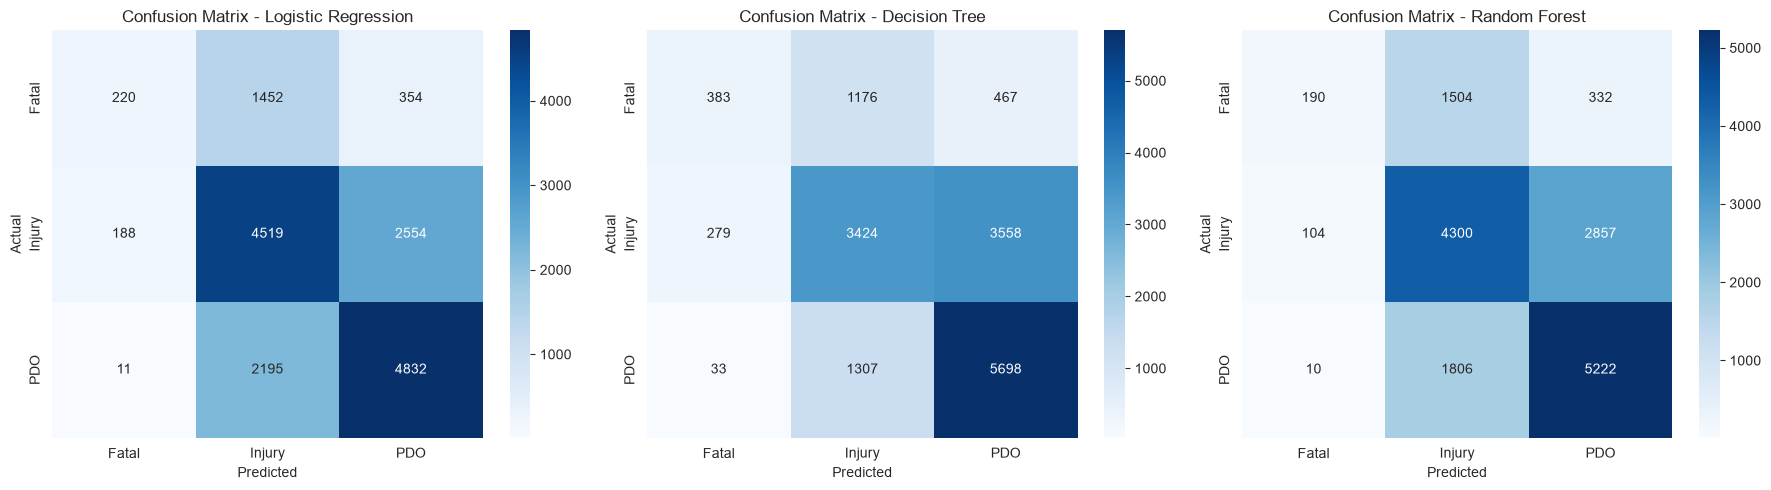

In [29]:
# [Quentin] - Confusion matrices for all 3 models side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'], labels=['Fatal', 'Injury', 'PDO'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fatal', 'Injury', 'PDO'], yticklabels=['Fatal', 'Injury', 'PDO'])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


In [30]:
# [Quentin] - Full per-class classification report (precision, recall, F1 per class)
for name, r in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, r['y_pred'], target_names=['Fatal', 'Injury', 'PDO']))



=== Logistic Regression ===
              precision    recall  f1-score   support

       Fatal       0.53      0.11      0.18      2026
      Injury       0.55      0.62      0.59      7261
         PDO       0.62      0.69      0.65      7038

    accuracy                           0.59     16325
   macro avg       0.57      0.47      0.47     16325
weighted avg       0.58      0.59      0.56     16325


=== Decision Tree ===
              precision    recall  f1-score   support

       Fatal       0.55      0.19      0.28      2026
      Injury       0.58      0.47      0.52      7261
         PDO       0.59      0.81      0.68      7038

    accuracy                           0.58     16325
   macro avg       0.57      0.49      0.49     16325
weighted avg       0.58      0.58      0.56     16325


=== Random Forest ===
              precision    recall  f1-score   support

       Fatal       0.62      0.09      0.16      2026
      Injury       0.57      0.59      0.58      7261


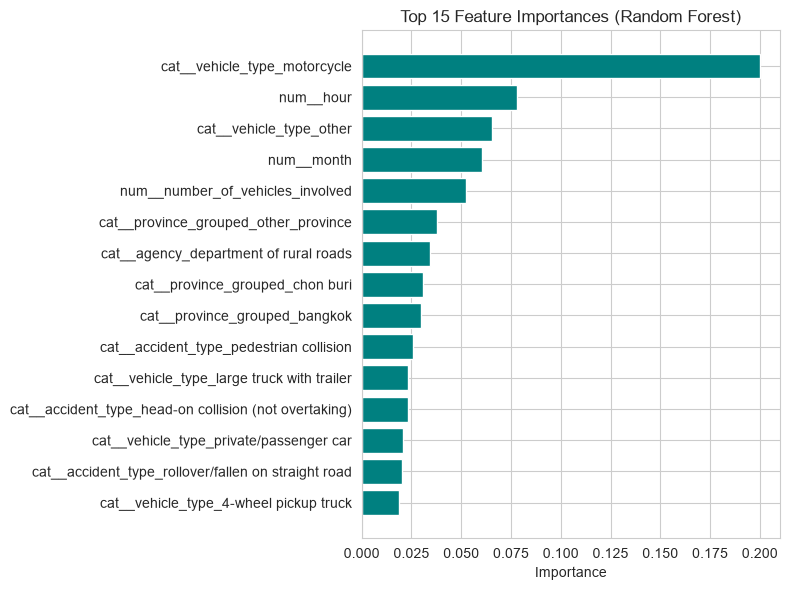

In [31]:
# [Quentin] - Feature importance from Random Forest (top contributing features)
rf_pipe = pipelines["Random Forest"]
feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipe.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(importance_df['feature'], importance_df['importance'], color='teal')
ax.invert_yaxis()
ax.set_title("Top 15 Feature Importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()
